# DCC-GARCH Framework - Introduction & Objective

Comprehensive notebook combines Dynamic Conditional Correlation (DCC) modeling with various machine learning approaches for portfolio optimization:

Main Components:

### 1. DCC-GARCH Framework (similar to the `Covariance_estimation_daily.ipynb` notebook):

* Multiple shrinkage methods (S, L1, L2, NL)
* GARCH(1,1) volatility modeling
* DCC parameter estimation using Optuna

### 2. Advanced Returns Prediction Methods:

* Gradient Boosting: Random Forest, CatBoost, LightGBM with extensive feature engineering
* Multi-Layer Perceptron (MLP): Deep neural network with PCA dimensionality reduction
* Convolutional Neural Network (CNN): 1D convolutions for time series prediction
* Feature creation includes: lagged returns/volatility, moving averages, RSI, Bollinger Bands, etc.

### 3. Portfolio Optimization:

* Custom covariance/mean estimators using predicted H_t matrices
* Integration with skfolio library
* Supports both "Minimize Volatility" and "Maximize Sharpe Ratio" objectives
* Weight constraints and budget controls

### 4. Backtesting Framework:

* DCC_strategy_report() function simulates actual trading
* Includes transaction costs and leverage
* Compares DCC-optimized vs equal-weighted portfolios
* Tracks capital evolution over time

### 5. Multiple Prediction Kernels:

* BASE_EMA (exponential moving average)
* ADVANCED_GRADIENT_BOOSTING_MACHINE
* MULTI_LAYER_PERCEPTRONE
* CONVOLUTIONAL_NEURAL_NETWORK
* And more...

The notebook demonstrates a sophisticated workflow combining econometric models (DCC-GARCH) with modern machine learning for return prediction, then using both for portfolio optimization and backtesting.

### Typical workflow

1. Choose tickers and date window.

1. `r, r_out = returns_preparation(...)`.

1. Fit per-asset GARCH with Optuna → `d, D_t_list`.

1. Compute `eps = r/d`, pick shrinkage, estimate `(α,β)`, build `Q_t_list`.

1. Roll into OOS with `eps_out` and `initial_Q = last Q_in`.

1. Convert to `H_t_list_out`.

1. Select a μ engine (EMA/GBM/MLP/CNN) → `returns_list`.

1. Optimise weights each step using `H_t` and `μ_t`.

1. Run `DCC_strategy_report` and compare vs equal-weight.

### What you get out

* Time series of portfolio weights, capital curves (DCC vs EW), and summary metrics (Sharpe, mean/vol, DCC params).

* Access to all intermediate artefacts (per-asset GARCH params, dynamic R_t/H_t, ML predictions) for diagnostics and figures.

In [ ]:
!pip install optuna seaborn skfolio arch catboost

## Data download and functions
See previous covariance notebooks for more detailed explaination

In [1]:
# Libraries for DCC and portfolio optimization
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
from statsmodels.tsa.stattools import adfuller
import warnings
import os
from scipy.stats import linregress
from arch import arch_model
from skfolio.prior import EmpiricalPrior
from skfolio.optimization import MeanRisk, ObjectiveFunction
from skfolio.measures import RiskMeasure
from skfolio.portfolio import Portfolio
from skfolio.moments import BaseCovariance, BaseMu

In [2]:
# Libraries for returns prediction
from datetime import date, datetime, timedelta, time
from statsmodels.tsa.stattools import adfuller
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM

In [3]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

#### Data Preparation & Pre-Processing

In [4]:
DOW_JONES = [
    'AMZN', 'AXP', 'AMGN', 'AAPL', 'BA', 'CAT', 'CSCO', 'CVX',
    'GS', 'HD', 'GE', 'IBM', 'JNJ', 'KO', 'JPM', 'MCD', 'MMM',
    'MRK', 'MSFT', 'NKE', 'PG', 'SHW', 'UNH', 'CRM', 'NVDA',
    'VZ', 'V', 'WMT', 'DIS', 'T'
]
# excluded: TRV, changed to AT&T (ticker T)
# changed HON (to GE)

In [5]:
# base version
def compute_C_S(eps):
    return np.corrcoef(eps)

# L1 shrinkage
def compute_C_L1(eps):
    lw = LedoitWolf().fit(eps.T)
    C_shrunk = lw.covariance_
    D = np.sqrt(np.diag(C_shrunk))
    return C_shrunk / np.outer(D, D)

# L2 shrinkage
def compute_C_L2(eps):
    C = np.corrcoef(eps)
    N, T = eps.shape

    off_diag_indices = np.triu_indices(N, k=1)
    rho_bar = np.mean(C[off_diag_indices])
    pi_hat = 0
    for i in range(N):
        for j in range(i+1, N):
            z_i = eps[i] / np.std(eps[i])
            z_j = eps[i] / np.std(eps[i])

            cov_ij = np.mean(z_i * z_j) - np.mean(z_i) * np.mean(z_j)
            var_c_ij = np.mean((z_i * z_j - cov_ij)**2) / T

            pi_hat += var_c_ij

    gamma_hat = np.sum((C[off_diag_indices] - rho_bar)**2)
    delta = pi_hat / (pi_hat + gamma_hat)
    delta = min(max(delta, 0), 1)

    F = np.ones((N, N)) * rho_bar
    np.fill_diagonal(F, 1)
    C_L2 = (1 - delta) * C + delta * F
    return C_L2

  # Non-linear shrinkage (the most powerfull due to the article)
def compute_C_NL(eps, c=None):

    C = np.corrcoef(eps)
    N, T = eps.shape
    c = N / T if c is None else c

    eigenvalues, eigenvectors = np.linalg.eigh(C)

    lambda_minus = (1 - np.sqrt(c)) ** 2
    lambda_plus = (1 + np.sqrt(c)) ** 2

    shrunk_eigenvalues = np.zeros_like(eigenvalues)
    for i, lam in enumerate(eigenvalues):
        if lambda_minus <= lam <= lambda_plus:
            shrunk_eigenvalues[i] = 1.0
        else:
            shrunk_eigenvalues[i] = lam / (1 + c)

    Lambda_shrunk = np.diag(shrunk_eigenvalues)
    C_NL = eigenvectors @ Lambda_shrunk @ eigenvectors.T

    C_NL = (C_NL + C_NL.T) / 2
    min_eig = np.min(np.linalg.eigvals(C_NL))
    if min_eig < 0:
        C_NL += np.eye(N) * (-min_eig + 1e-6)

    return C_NL

### GARCH-Based Volatility Modelling
- Per-asset univariate GARCH(1,1) estimation using **Optuna**.  
- Equation:  

  $$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$
  
- Generate per-asset volatility series $ d_t $ and diagonal matrices $ D_t $.  
- Store fitted parameters for later diagnostics.  

In [6]:
def garch_objective(trial, returns, ticker):

    omega = trial.suggest_float(f'omega_{ticker}', 1e-6, 1e-4, log=True)
    alpha = trial.suggest_float(f'alpha_{ticker}', 0.01, 0.2)
    beta = trial.suggest_float(f'beta_{ticker}', 0.7, 0.99)

    if alpha + beta >= 1:
        return float('inf')

    try:
        sigma = compute_garch_volatility(returns, omega, alpha, beta)
        mu = np.mean(returns)
        residuals = returns - mu
        log_likelihood = -0.5 * np.sum(np.log(sigma**2) + (residuals**2 / sigma**2))

        return -log_likelihood
    except Exception as e:
        print(f'Trial for {ticker} failed: {e}')
        return float('inf')

def compute_garch_volatility(returns, omega, alpha, beta):

    n = len(returns)
    sigma2 = np.zeros(n)
    mu = np.mean(returns)
    epsilon = returns - mu

    sigma2[0] = np.var(returns)

    for t in range(1, n):
        sigma2[t] = omega + alpha * epsilon[t-1]**2 + beta * sigma2[t-1]

    return np.sqrt(sigma2)

def garch_for_all_assets_optuna(r, tickers, n_trials=50):

    n_assets, n_periods = r.shape
    params_dict = {}
    d = np.zeros((n_assets, n_periods))
    D_t_list = []

    for i, ticker in enumerate(tickers):
        print(f'GARCH(1,1) optimization for {ticker}:')
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: garch_objective(trial, r[i, :], ticker), n_trials=n_trials)

        best_params = study.best_params
        omega = best_params[f'omega_{ticker}']
        alpha = best_params[f'alpha_{ticker}']
        beta = best_params[f'beta_{ticker}']

        params_dict[ticker] = {'omega': omega, 'alpha': alpha, 'beta': beta}
        d[i, :] = compute_garch_volatility(r[i, :], omega, alpha, beta)

    for t in range(n_periods):
        D_t_list.append(np.diag(d[:, t]))

    return params_dict, d, D_t_list

### DCC-GARCH Framework

- Implement Dynamic Conditional Correlation (DCC) model:  

  $$Q_t = (1 - \alpha - \beta)C + \alpha s_{t-1}s_{t-1}^\top + \beta Q_{t-1}$$
  
- Optimise parameters $ (\alpha_{\text{DCC}}, \beta_{\text{DCC}}) $ using **Optuna**.  
- Compute and normalise conditional correlation matrices $ R_t $.  
- Reconstruct conditional covariance matrices:  

  $$H_t = D_t R_t D_t$$

- Multiple shrinkage options for unconditional correlation $ C $:  
  - Sample (S)  
  - Ledoit–Wolf (L1)  
  - Linear Shrinkage (L2)  
  - Non-Linear Shrinkage (NL)  

In [7]:
def composite_dcc_log_likelihood_optuna(params, eps, shrinkage='S'):

    alpha, beta = params
    n_assets, n_periods = eps.shape

    if alpha < 0 or beta < 0 or alpha + beta >= 1:
        return np.inf

    if shrinkage == 'S':
        C = compute_C_S(eps)
    elif shrinkage == 'L1':
        C = compute_C_L1(eps)
    elif shrinkage == 'L2':
        C = compute_C_L2(eps)
    elif shrinkage == 'NL':
        C = compute_C_NL(eps)
    else:
        raise ValueError(f'Unknown shrinkage method: {shrinkage}')

    Q_t = C
    log_likelihood = 0

    for t in range(1, n_periods):
        s_t1 = eps[:, t-1].reshape(-1, 1)
        Q_t = (1 - alpha - beta) * C + alpha * (s_t1 @ s_t1.T) + beta * Q_t
        Q_t_diag = np.sqrt(np.diag(Q_t))
        R_t = Q_t / (Q_t_diag[:, None] * Q_t_diag[None, :])

        for i in range(n_assets):
            for j in range(i + 1, n_assets):
                r_ij = R_t[i, j]
                if abs(r_ij) >= 1:
                    return np.inf
                eps_i_t = eps[i, t]
                eps_j_t = eps[j, t]
                log_likelihood -= 0.5 * (
                    np.log(1 - r_ij**2) +
                    (eps_i_t**2 + eps_j_t**2 - 2 * r_ij * eps_i_t * eps_j_t) / (1 - r_ij**2)
                )

    return -log_likelihood

In [8]:
def estimate_dcc_params_optuna(eps, shrinkage='S', n_trials=50):

    def objective(trial):

        #alpha = trial.suggest_float('alpha', 1e-5, 0.2)
        #beta = trial.suggest_float('beta', 0.7, 0.99)
        alpha = trial.suggest_float('alpha', 0.03, 0.03)
        beta = trial.suggest_float('beta', 0.94, 0.94)
        params = [alpha, beta]

        return composite_dcc_log_likelihood_optuna(params, eps, shrinkage)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params
    alpha = best_params['alpha']
    beta = best_params['beta']

    if study.best_value == np.inf:
        raise ValueError('DCC optimization failed')

    return np.array([alpha, beta])

def compute_Q_t_optuna(eps, alpha, beta, shrinkage='S', initial_Q=None):

    n_assets, n_periods = eps.shape

    if shrinkage == 'S':
        C = compute_C_S(eps)
    elif shrinkage == 'L1':
        C = compute_C_L1(eps)
    elif shrinkage == 'L2':
        C = compute_C_L2(eps)
    elif shrinkage == 'NL':
        C = compute_C_NL(eps)
    else:
        raise ValueError(f'Unknown shrinkage method: {shrinkage}')

    Q_t_list = []
    Q_t = initial_Q if initial_Q is not None else C

    for t in range(n_periods):
        Q_t_list.append(Q_t)
        if t < n_periods - 1:
            s_t = eps[:, t].reshape(-1, 1)
            Q_t = (1 - alpha - beta) * C + alpha * (s_t @ s_t.T) + beta * Q_t

    return Q_t_list, C

In [9]:
def compute_garch_volatility_test(returns, omega, alpha, beta, initial_sigma2=None):

    n = len(returns)
    sigma2 = np.zeros(n)
    mu = np.mean(returns)
    epsilon = returns - mu

    if initial_sigma2 is None:
        sigma2[0] = np.var(returns)
    else:
        sigma2[0] = initial_sigma2

    for t in range(1, n):
        sigma2[t] = omega + alpha * epsilon[t-1]**2 + beta * sigma2[t-1]

    return np.sqrt(sigma2)

def garch_for_test_data(r_out, tickers, params_dict, initial_vols=None):

    n_assets, n_periods = r_out.shape
    d_out = np.zeros((n_assets, n_periods))
    D_t_list_out = []

    for i, ticker in enumerate(tickers):
        omega = params_dict[ticker]['omega']
        alpha = params_dict[ticker]['alpha']
        beta = params_dict[ticker]['beta']
        initial_sigma2 = initial_vols[i] if initial_vols is not None else None
        d_out[i, :] = compute_garch_volatility_test(r_out[i, :], omega, alpha, beta, initial_sigma2)

    for t in range(n_periods):
        D_t_list_out.append(np.diag(d_out[:, t]))

    return d_out, D_t_list_out

In [10]:
def compute_R_t_H_t(Q_t_list, D_t_list):

    R_t_list = []
    H_t_list = []

    for t in range(len(Q_t_list)):
        Q_t = Q_t_list[t]

        Q_t_diag_sqrt = np.sqrt(np.diag(Q_t))
        Q_t_diag_inv_sqrt = np.diag(1 / Q_t_diag_sqrt)

        R_t = Q_t_diag_inv_sqrt @ Q_t @ Q_t_diag_inv_sqrt
        R_t_list.append(R_t)
        D_t = D_t_list[t]
        H_t = D_t @ R_t @ D_t
        H_t_list.append(H_t)

    return R_t_list, H_t_list

def compute_ema_returns(r_out, window=60):

    n_assets, n_periods = r_out.shape
    alpha = 2 / (window + 1)
    returns_list = []
    # EMA initialization
    ema = np.mean(r_out[:, :window], axis=1)
    # EMA for t < window
    for t in range(window):
        returns_list.append(ema.copy())
    # EMA for t >= window
    for t in range(window, n_periods):
        ema = alpha * r_out[:, t-1] + (1 - alpha) * ema
        returns_list.append(ema.copy())

    return returns_list

In [41]:
def returns_preparation(DOW_JONES, frequency='15MIN', perspective='LONG',
                        train_fraction=0.8, start_overall='2010-01-04 14:30:00',
                        end_overall='2011-01-04 14:30:00', date_format='%Y-%m-%dT%H:%M:%SZ'):

    ticker = 'AMZN'
    data = pd.read_csv(f'DOW_JONES_{frequency}_{perspective}/{ticker}.csv', index_col='timestamp')
    data.index = pd.to_datetime(data.index, format=date_format)
    data[f'log_ret_start'] = np.log(data['close'] / data['close'].shift(1))
    columns_to_drop = [
        'open', 'high', 'low', 'close', 'volume',
        'year', 'month', 'day', 'hour', 'minute',
        'weekday', 'is_monday', 'week_of_month',
        'is_third_friday', 'is_trade_session_start',
        'is_trade_session_end', 'real_vol', 'log_ret'
                      ]
    data = data.drop(columns_to_drop, axis=1, errors='ignore')
    data = data.fillna(0)
    for ticker in DOW_JONES:
        data_new = pd.read_csv(f'DOW_JONES_{frequency}_{perspective}/{ticker}.csv', index_col='timestamp')
        data_new.index = pd.to_datetime(data_new.index, format=date_format)
        data_new[f'log_ret_{ticker}'] = np.log(data_new['close'] / data_new['close'].shift(1))
        data_new = data_new.drop(columns_to_drop, axis=1, errors='ignore')
        data_new = data_new.fillna(0)
        data = pd.concat([data, data_new], axis=1)

    data = data.drop(data.columns[0], axis=1, errors='ignore')
    data = data.fillna(0)

    req_start = pd.to_datetime(start_overall)
    req_end = pd.to_datetime(end_overall)
    potential_starts = data.index[data.index >= req_start]
    if len(potential_starts) == 0:
        raise ValueError(f'No data available at or after {req_start}')
    actual_start = potential_starts[0]
    potential_ends = data.index[data.index <= req_end]
    if len(potential_ends) == 0:
        raise ValueError(f'No data available at or before {req_end}')
    actual_end = potential_ends[-1]
    if actual_end < actual_start:
        raise ValueError(f'Actual end {actual_end} is before actual start {actual_start}')
    data_range = data.loc[actual_start:actual_end]
    train_size = int(train_fraction * len(data_range))
    X_train = data_range[:train_size]
    X_test = data_range[train_size:]
    r = X_train.to_numpy().T
    r_out = X_test.to_numpy().T

    return r, r_out

In [43]:
r, r_out = returns_preparation(DOW_JONES, frequency='15MIN', perspective='LONG',
                        train_fraction=0.8, start_overall='2010-01-04 14:30:00',
                        end_overall='2011-01-04 14:30:00', date_format='%Y-%m-%dT%H:%M:%SZ')

In [45]:
print(len(r_out))

18


## Machine Learning–Driven Return Prediction

In [12]:
class CustomCovariance(BaseCovariance):
    def __init__(self, H_t=None):
        super().__init__()
        self.H_t = H_t

    def fit(self, X, y=None):
        if self.H_t is None:
            raise ValueError('H_t is empty')
        self._set_covariance(self.H_t)
        return self

class CustomMu(BaseMu):
    def __init__(self, mu=None):
        super().__init__()
        self.mu = mu

    def fit(self, X, y=None):
        if self.mu is None:
            raise ValueError('Empty mu')
        self.mu_ = self.mu
        return self

**Portfolio Optimisation Framework**

- Integrate dynamic covariance $ H_t $ and predicted means $ \mu_t $ into **skfolio** optimisers.  

- Objective functions:  
  - **Minimise Volatility**  
  - **Maximise Sharpe Ratio**  

- Weight constraints, budget controls, and leverage options.  
- Outputs time-series of optimal portfolio weights.

In [13]:
def optimize_portfolio_weights_h_t_list_with_returns(H_t_list,
    returns_list, tickers, goal_function='Volatility', min_weight=None, max_weight=None, budget=1):

    n_assets = len(tickers)
    weights_list = []

    for t, (H_t, mu) in enumerate(zip(H_t_list, returns_list)):

        if goal_function == 'Volatility':

            try:
                covariance_estimator = CustomCovariance(H_t=H_t)
                mu_estimator = CustomMu(mu=mu)
                prior_estimator = EmpiricalPrior(
                    covariance_estimator=covariance_estimator,
                    mu_estimator=mu_estimator
                )
                model = MeanRisk(
                    risk_measure=RiskMeasure.STANDARD_DEVIATION,
                    objective_function=ObjectiveFunction.MINIMIZE_RISK,
                    prior_estimator=prior_estimator,
                    budget=budget,
                    min_weights=min_weight,
                    max_weights=max_weight
                )
                X_dummy = np.zeros((1, n_assets))
                model.fit(X=X_dummy)
                weights = model.weights_
                weights_list.append(weights)

            except Exception as e:
                print(f'Optimization failed for t={t+1}: {e}')
                weights_list.append(np.ones(n_assets) / n_assets)


        elif goal_function == 'Sharpe Ratio':

            try:
                covariance_estimator = CustomCovariance(H_t=H_t)
                mu_estimator = CustomMu(mu=mu)
                prior_estimator = EmpiricalPrior(
                    covariance_estimator=covariance_estimator,
                    mu_estimator=mu_estimator
                )
                model = MeanRisk(
                    risk_measure=RiskMeasure.STANDARD_DEVIATION,
                    objective_function=ObjectiveFunction.MAXIMIZE_RATIO,
                    prior_estimator=prior_estimator,
                    budget=budget,
                    min_weights=min_weight,
                    max_weights=max_weight
                )
                X_dummy = np.zeros((1, n_assets))
                model.fit(X=X_dummy)
                weights = model.weights_
                weights_list.append(weights)

            except Exception as e:
                print(f'Optimization failed for t={t+1}: {e}')
                weights_list.append(np.ones(n_assets) / n_assets)

    return weights_list

In [14]:
SharpeScalarDict = {
    '1MIN': 390,
    '15MIN': 26,
    '30MIN': 13,
    '3INTERVALS': 3,
    'DAILY': 1
}
DateFormatDict = {
    '1MIN': '%Y-%m-%dT%H:%M:%SZ',
    '15MIN': '%Y-%m-%dT%H:%M:%SZ',
    '30MIN': '%Y-%m-%d %H:%M:%S',
    '3INTERVALS': '%Y-%m-%d %H:%M:%S',
    'DAILY': '%Y-%m-%d'
}
FilesLengthsDict = {
    '1MIN': (521807, 1515013),
    '15MIN': (34816, 101200),
    '30MIN': (17413, 50630),
    '3INTERVALS': (3999, 11517),
    'DAILY': (1343, 3895)
}

- Multiple predictive engines producing expected returns $ \mu_t $:

  - **BASE_EMA**: simple exponential moving average.  
  - **ADVANCED_GRADIENT_BOOSTING_MACHINE**: CatBoost / LightGBM with engineered features.  
  - **MULTI_LAYER_PERCEPTRON (MLP)**: dense network with PCA-reduced features.  
  - **CONVOLUTIONAL_NEURAL_NETWORK (CNN)**: 1D CNN layers for temporal feature extraction.  

- Feature engineering:

  - Lagged returns and volatilities.  
  - Moving averages, RSI, Bollinger Bands, rolling correlations, etc.  

- Scalable to additional kernels for comparative testing.


In [15]:
# Creating features for gradient boosting model
def create_features_gradient_boosting(data):
    new_cols = {}
    excluded_cols = []
    data['realized_vol'] = data['log_ret'] ** 2
    data['price'] = np.exp(np.cumsum(data['log_ret'].fillna(0)))

    new_cols['realized_vol'] = data['log_ret'] ** 2
    if new_cols['realized_vol'].isna().all():
        excluded_cols.append('realized_vol')
        del new_cols['realized_vol']

    new_cols['target_ret'] = data['log_ret'].shift(-1)
    if new_cols['target_ret'].isna().all():
        excluded_cols.append('target_ret')
        del new_cols['target_ret']

    new_cols['price'] = np.exp(np.cumsum(data['log_ret'].fillna(0)))
    if new_cols['price'].isna().all():
        excluded_cols.append('price')
        del new_cols['price']

    lags = [1, 2, 5, 10, 20, 36, 60, 120]
    for lag in lags:
        new_cols[f'lag_vol_{lag}'] = data['realized_vol'].shift(lag)
        if new_cols[f'lag_vol_{lag}'].isna().all():
            excluded_cols.append(f'lag_vol_{lag}')
            del new_cols[f'lag_vol_{lag}']
            continue
        new_cols[f'lag_ret_{lag}'] = data['log_ret'].shift(lag)
        if new_cols[f'lag_ret_{lag}'].isna().all():
            excluded_cols.append(f'lag_ret_{lag}')
            del new_cols[f'lag_ret_{lag}']
            continue
        new_cols[f'abs_ret_{lag}'] = data['log_ret'].abs().shift(lag)
        if new_cols[f'abs_ret_{lag}'].isna().all():
            excluded_cols.append(f'abs_ret_{lag}')
            del new_cols[f'abs_ret_{lag}']

    ma_windows = [4, 5, 10, 15, 20, 30, 60, 120]
    for window in ma_windows:
        new_cols[f'ma_vol_{window}'] = data['realized_vol'].rolling(window).mean()
        if new_cols[f'ma_vol_{window}'].isna().all():
            excluded_cols.append(f'ma_vol_{window}')
            del new_cols[f'ma_vol_{window}']

    std_windows = [5, 10, 30, 60, 120]
    for window in std_windows:
        new_cols[f'std_vol_{window}'] = data['realized_vol'].rolling(window).std()
        if new_cols[f'std_vol_{window}'].isna().all():
            excluded_cols.append(f'std_vol_{window}')
            del new_cols[f'std_vol_{window}']

    same_n = [5, 10, 20, 30, 50]
    for n in same_n:
        new_cols[f'ma_ret_same_{n}'] = data.groupby('intra_day_period')['log_ret'].transform(lambda x: x.shift(1).rolling(n).mean())
        if new_cols[f'ma_ret_same_{n}'].isna().all():
            excluded_cols.append(f'ma_ret_same_{n}')
            del new_cols[f'ma_ret_same_{n}']
            continue
        new_cols[f'ma_vol_same_{n}'] = data.groupby('intra_day_period')['realized_vol'].transform(lambda x: x.shift(1).rolling(n).mean())
        if new_cols[f'ma_vol_same_{n}'].isna().all():
            excluded_cols.append(f'ma_vol_same_{n}')
            del new_cols[f'ma_vol_same_{n}']
            continue
        new_cols[f'std_ret_same_{n}'] = data.groupby('intra_day_period')['log_ret'].transform(lambda x: x.shift(1).rolling(n).std())
        if new_cols[f'std_ret_same_{n}'].isna().all():
            excluded_cols.append(f'std_ret_same_{n}')
            del new_cols[f'std_ret_same_{n}']
            continue
        new_cols[f'std_vol_same_{n}'] = data.groupby('intra_day_period')['realized_vol'].transform(lambda x: x.shift(1).rolling(n).std())
        if new_cols[f'std_vol_same_{n}'].isna().all():
            excluded_cols.append(f'std_vol_same_{n}')
            del new_cols[f'std_vol_same_{n}']

    rsi_windows = [10, 14, 20, 30, 50]
    for window in rsi_windows:
        deltas = data['price'].diff()
        gain = deltas.where(deltas > 0, 0).rolling(window=window).mean()
        loss = -deltas.where(deltas < 0, 0).rolling(window=window).mean()
        rs = gain / loss
        new_cols[f'rsi_{window}'] = 100 - (100 / (1 + rs))
        if new_cols[f'rsi_{window}'].isna().all():
            excluded_cols.append(f'rsi_{window}')
            del new_cols[f'rsi_{window}']

    bb_windows = [10, 20, 50]
    for window in bb_windows:
        ma = data['price'].rolling(window).mean()
        std = data['price'].rolling(window).std()
        new_cols[f'bb_mid_{window}'] = ma
        if new_cols[f'bb_mid_{window}'].isna().all():
            excluded_cols.append(f'bb_mid_{window}')
            del new_cols[f'bb_mid_{window}']
            continue
        new_cols[f'bb_upper_{window}'] = ma + 2 * std
        if new_cols[f'bb_upper_{window}'].isna().all():
            excluded_cols.append(f'bb_upper_{window}')
            del new_cols[f'bb_upper_{window}']
            continue
        new_cols[f'bb_lower_{window}'] = ma - 2 * std
        if new_cols[f'bb_lower_{window}'].isna().all():
            excluded_cols.append(f'bb_lower_{window}')
            del new_cols[f'bb_lower_{window}']

    data = pd.concat([data, pd.DataFrame(new_cols, index=data.index)], axis=1)

    data = data.dropna()

    if excluded_cols:
        print(f'Excluded columns due to all NaN or invalid values: {', '.join(excluded_cols)}')

    return data

In [28]:
def ADVANCED_GRADIENT_BOOSTING_MACHINE(ticker, start_overall, end_overall, engine='CatBoost', num_iters=20, train_fraction=0.8):

    file_path = f'TIMESTAMPS_FOR_NEURAL_NETWORKS_DAILY/{ticker}.csv'
    data = pd.read_csv(file_path)
    data['date'] = pd.to_datetime(data['timestamp'])
    data = data.set_index('date').sort_index()
    req_start = pd.to_datetime(start_overall)
    req_end = pd.to_datetime(end_overall)
    potential_starts = data.index[data.index >= req_start]
    if len(potential_starts) == 0:
        raise ValueError(f'No data available at or after {req_start}')
    actual_start = potential_starts[0]
    potential_ends = data.index[data.index <= req_end]
    if len(potential_ends) == 0:
        raise ValueError(f'No data available at or before {req_end}')
    actual_end = potential_ends[-1]
    if actual_end < actual_start:
        raise ValueError(f'Actual end {actual_end} is before actual start {actual_start}')

    data_range = data.loc[actual_start:actual_end]
    if len(data_range) < 2:
        raise ValueError('Not enough raw data in the specified range.')

    data_range = create_features_gradient_boosting(data_range)
    total_obs = len(data_range)
    if total_obs < 2:
        raise ValueError('Not enough data in the specified range after feature creation.')

    excluded_cols = ['log_ret', 'realized_vol', 'target_ret', 'price', 'timestamp']
    features = [col for col in data_range.columns if col not in excluded_cols]

    train_size = int(train_fraction * total_obs)

    if train_size == 0 or train_size == total_obs:
        train_size = max(1, total_obs - 1)

    train_data = data_range.iloc[:train_size]
    test_data = data_range.iloc[train_size:]

    X_train = train_data[features]
    y_train = train_data['target_ret']
    X_test = test_data[features]
    y_test = test_data['target_ret']

    if engine == 'Random Forest':
        model = RandomForestRegressor(n_estimators=num_iters, random_state=42)
    elif engine == 'CatBoost':
        model = CatBoostRegressor(iterations=num_iters, random_seed=42, verbose=0)
    elif engine == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=num_iters, random_state=42)
    else:
        raise ValueError("Invalid engine. Choose 'Random Forest', 'CatBoost', or 'LightGBM'.")

    model.fit(X_train, y_train)
    r_pred = model.predict(X_test)
    r2 = r2_score(y_test, r_pred)

    return y_test, r_pred, r2

In [27]:
def ADVANCED_GRADIENT_BOOSTING_MACHINE_NEW(ticker,
    start_overall, end_overall, engine='CatBoost', num_iters=20, importance_factor=20, train_fraction=0.8):

    file_path = f'TIMESTAMPS_FOR_NEURAL_NETWORKS_DAILY/{ticker}.csv'
    data = pd.read_csv(file_path)
    data['date'] = pd.to_datetime(data['timestamp'])
    data = data.set_index('date').sort_index()

    req_start = pd.to_datetime(start_overall)
    req_end = pd.to_datetime(end_overall)

    potential_starts = data.index[data.index >= req_start]
    if len(potential_starts) == 0:
        raise ValueError(f'No data available at or after {req_start}')
    actual_start = potential_starts[0]

    potential_ends = data.index[data.index <= req_end]
    if len(potential_ends) == 0:
        raise ValueError(f'No data available at or before {req_end}')
    actual_end = potential_ends[-1]

    if actual_end < actual_start:
        raise ValueError(f'Actual end {actual_end} is before actual start {actual_start}')

    data_range = data.loc[actual_start:actual_end]

    if len(data_range) < 2:
        raise ValueError('Not enough raw data in the specified range.')
    data_range = create_features_gradient_boosting(data_range)

    total_obs = len(data_range)
    if total_obs < 2:
        raise ValueError('Not enough data in the specified range after feature creation.')

    excluded_cols = ['log_ret', 'realized_vol', 'target_ret', 'price', 'timestamp']
    features = [col for col in data_range.columns if col not in excluded_cols]

    train_size = int(train_fraction * total_obs)
    if train_size == 0 or train_size == total_obs:
        train_size = max(1, total_obs - 1)

    train_data = data_range.iloc[:train_size]
    test_data = data_range.iloc[train_size:]

    X_train = train_data[features]
    y_train = train_data['target_ret']
    X_test = test_data[features]
    y_test = test_data['target_ret']

    if engine == 'Random Forest':
        model = RandomForestRegressor(n_estimators=num_iters, random_state=42)
    elif engine == 'CatBoost':
        model = CatBoostRegressor(iterations=num_iters, random_seed=42, verbose=0)
    elif engine == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=num_iters, random_state=42)
    else:
        raise ValueError("Invalid engine. Choose 'Random Forest', 'CatBoost', or 'LightGBM'.")

    model.fit(X_train, y_train)

    if engine == 'LightGBM' or engine == 'Random Forest':
        importance = model.feature_importances_
    elif engine == 'CatBoost':
        importance = model.get_feature_importance(type='PredictionValuesChange')

    feature_names = X_train.columns
    fi_df = pd.DataFrame({'Feature name': feature_names, 'Importance': importance})
    fi_df = fi_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature name', data=fi_df.head(importance_factor))
    plt.title(f'{engine} feature importance ranking')
    plt.xlabel('Feature importance')
    plt.ylabel('Feature name')
    plt.show()

    r_pred_all = model.predict(X_test)
    r2_all = r2_score(y_test, r_pred_all)
    top_features = fi_df['Feature name'].head(importance_factor).tolist()

    X_train_top = X_train[top_features]
    X_test_top = X_test[top_features]

    if engine == 'Random Forest':
        model_top = RandomForestRegressor(n_estimators=num_iters, random_state=42)
    elif engine == 'CatBoost':
        model_top = CatBoostRegressor(iterations=num_iters, random_seed=42, verbose=0)
    elif engine == 'LightGBM':
        model_top = lgb.LGBMRegressor(n_estimators=num_iters, random_state=42)

    model_top.fit(X_train_top, y_train)
    r_pred_top = model_top.predict(X_test_top)
    r2_top = r2_score(y_test, r_pred_top)

    return y_test, r_pred_all, r2_all, r_pred_top, r2_top

In [26]:
def MULTI_LAYER_PERCEPTRONE_WITH_PCA_MACHINE(ticker, start_overall, end_overall, num_epochs=50, train_fraction=0.8, variance_threshold=0.9, optimizer='adam', loss='mse', scaler_type='standard'):

    file_path = f'TIMESTAMPS_FOR_NEURAL_NETWORKS_DAILY/{ticker}.csv'
    data = pd.read_csv(file_path)
    data['date'] = pd.to_datetime(data['timestamp'])
    data = data.set_index('date').sort_index()

    req_start = pd.to_datetime(start_overall)
    req_end = pd.to_datetime(end_overall)

    potential_starts = data.index[data.index >= req_start]
    if len(potential_starts) == 0:
        raise ValueError(f'No data available at or after {req_start}')
    actual_start = potential_starts[0]

    potential_ends = data.index[data.index <= req_end]
    if len(potential_ends) == 0:
        raise ValueError(f'No data available at or before {req_end}')
    actual_end = potential_ends[-1]

    if actual_end < actual_start:
        raise ValueError(f'Actual end {actual_end} is before actual start {actual_start}')

    data_range = data.loc[actual_start:actual_end]

    if len(data_range) < 2:
        raise ValueError('Not enough raw data in the specified range')

    data_range = create_features_gradient_boosting(data_range)

    total_obs = len(data_range)
    if total_obs < 2:
        raise ValueError('Not enough data in the specified range after feature creation')

    excluded_cols = ['log_ret', 'realized_vol', 'target_ret', 'price', 'timestamp', 'open', 'high', 'low', 'close']
    features = [col for col in data_range.columns if col not in excluded_cols]

    train_size = int(train_fraction * total_obs)
    if train_size == 0 or train_size == total_obs:
        train_size = max(1, total_obs - 1)

    train_data = data_range.iloc[:train_size]
    test_data = data_range.iloc[train_size:]

    X_train = train_data[features].values
    y_train = train_data['target_ret'].values
    X_test = test_data[features].values
    y_test = test_data['target_ret'].values

    if scaler_type == 'standard':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    elif scaler_type == 'none':
        pass
    else:
        raise ValueError(f'Invalid scaler_type: {scaler_type}')

    # PCA
    pca = PCA()
    pca.fit(X_train)
    cum_var = np.cumsum(pca.explained_variance_ratio_)
    n_components = np.where(cum_var >= variance_threshold)[0][0] + 1 if np.any(cum_var >= variance_threshold) else X_train.shape[1]
    pca = PCA(n_components=n_components)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)

    model = Sequential([
        Dense(4096, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(2048, activation='relu'),
        Dropout(0.4),
        Dense(1024, activation='relu'),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dense(64, activation='tanh'),
        Dense(32, activation='tanh'),
        Dense(1)
    ])

    model.compile(optimizer=optimizer, loss=loss)

    model.fit(X_train, y_train, epochs=num_epochs, batch_size=16, verbose=1, validation_split=0.2)

    r_pred = model.predict(X_test, verbose=0).flatten()

    r2 = r2_score(y_test, r_pred)

    return r_pred, y_test, r2

In [25]:
def ADVANCED_CONVOLUTIONAL_NEURAL_NETWORK_MACHINE_WITH_PCA(ticker, start_overall, end_overall, principal_components=True,
    num_epochs=50, train_fraction=0.8, variance_threshold=0.9, optimizer='adam', loss='mse', scaler_type='standard'):

    file_path = f'TIMESTAMPS_FOR_NEURAL_NETWORKS_DAILY/{ticker}.csv'
    data = pd.read_csv(file_path)
    data['date'] = pd.to_datetime(data['timestamp'])
    data = data.set_index('date').sort_index()

    req_start = pd.to_datetime(start_overall)
    req_end = pd.to_datetime(end_overall)

    potential_starts = data.index[data.index >= req_start]
    if len(potential_starts) == 0:
        raise ValueError(f'No data available at or after {req_start}')
    actual_start = potential_starts[0]

    potential_ends = data.index[data.index <= req_end]
    if len(potential_ends) == 0:
        raise ValueError(f'No data available at or before {req_end}')
    actual_end = potential_ends[-1]

    if actual_end < actual_start:
        raise ValueError(f'Actual end {actual_end} is before actual start {actual_start}')

    data = create_features_gradient_boosting(data)
    data_range = data.loc[actual_start:actual_end]

    total_obs = len(data_range)
    if total_obs < 2:
        raise ValueError('Not enough data in the specified range after feature creation')

    excluded_cols = ['log_ret', 'realized_vol', 'target_ret', 'price', 'timestamp', 'open', 'high', 'low', 'close']
    features = [col for col in data_range.columns if col not in excluded_cols]

    train_size = int(train_fraction * total_obs)
    if train_size == 0 or train_size == total_obs:
        train_size = max(1, total_obs - 1)

    train_data = data_range.iloc[:train_size]
    test_data = data_range.iloc[train_size:]

    actual_start_train = train_data.index[0]
    actual_end_train = train_data.index[-1]
    actual_end_test = test_data.index[-1]

    print(f'Real training started at: {actual_start_train}')
    print(f'Real training ended at: {actual_end_train}')
    print(f'Real testing ended at: {actual_end_test}')

    X_train = train_data[features].values
    y_train = train_data['target_ret'].values
    X_test = test_data[features].values
    y_test = test_data['target_ret'].values

    if scaler_type == 'standard':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    elif scaler_type == 'none':
        pass
    else:
        raise ValueError(f'Invalid scaler_type: {scaler_type}')

    if principal_components == True:
        pca = PCA()
        pca.fit(X_train)
        cum_var = np.cumsum(pca.explained_variance_ratio_)
        n_components = np.where(cum_var >= variance_threshold)[0][0] + 1 if np.any(cum_var >= variance_threshold) else X_train.shape[1]
        pca = PCA(n_components=n_components)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Build CNN model with padding='same' to preserve sequence length
    model = Sequential([
        Conv1D(filters=16, kernel_size=5, activation='relu', padding='same', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(X_train.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='tanh'),
        Dense(1)
    ])

    model.compile(optimizer=optimizer, loss=loss)

    model.fit(X_train, y_train, epochs=num_epochs, batch_size=16, verbose=0, validation_split=0.2)

    r_pred = model.predict(X_test, verbose=0).flatten()
    r2 = r2_score(y_test, r_pred)

    return r_pred, y_test, r2, actual_start_train, actual_end_train, actual_end_test

#### Test run ADVANCED_GRADIENT_BOOSTING_MACHINE

In [29]:
r_pred, y_test, r2 = ADVANCED_GRADIENT_BOOSTING_MACHINE(
                        'MMM', '2021-01-01', '2023-09-28'
        )

In [30]:
print(r2)

-0.039025415072790004


#### Test run ADVANCED_CONVOLUTIONAL_NEURAL_NETWORK_MACHINE_WITH_PCA

In [31]:
r_pred, y_test, r2, actual_start_train, actual_end_train, actual_end_test = ADVANCED_CONVOLUTIONAL_NEURAL_NETWORK_MACHINE_WITH_PCA(
                        'MMM', '2021-01-01', '2023-09-28', principal_components=False, num_epochs=30,
                        train_fraction=0.8, variance_threshold=0.95,
                        optimizer='adam', loss='mse', scaler_type='standard'
        )

Real training started at: 2021-01-04 00:00:00
Real training ended at: 2023-03-13 00:00:00
Real testing ended at: 2023-09-28 00:00:00


In [32]:
print(r2)

0.0089749428764474


### Backtesting & Performance Evaluation

In [46]:
def returns_prediction(r_out, DOW_JONES, data_length=1000, kernel='BASE_EMA', start='2015-01-01', end='2020-01-01',
    train_size=0.8):

    try:
        if kernel == 'ZEROS':
            returns_list == np.array([np.zeros(data_length) for _ in range(len(DOW_JONES))])

        if kernel == 'BASE_EMA':
            returns_list = compute_ema_returns(r_out, window=60)
            returns_list = np.array(returns_list)

        elif kernel == 'EMA_WITH_LEARNING':
            pass

        elif kernel == 'LINEAR_REGRESSION':
            pass
        elif kernel == 'LOGISTIC_REGRESSION':
            pass
        elif kernel == 'ADVANCED_GRADIENT_BOOSTING_MACHINE':
            returns_list = []
            for ticker in DOW_JONES:
                y_test, r_pred, r2 = ADVANCED_GRADIENT_BOOSTING_MACHINE(ticker,
                                    start, end, engine='CatBoost', num_iters=10, train_fraction=train_size)
                returns_list.append(r_pred)
            returns_list = np.array(returns_list)
            returns_list = returns_list.T

        elif kernel == 'ADVANCED_GRADIENT_BOOSTING_MACHINE_NEW':
            returns_list = []
            for ticker in DOW_JONES:
                y_test, r_pred_all, r2_all, r_pred_top, r2_top = ADVANCED_GRADIENT_BOOSTING_MACHINE_NEW(ticker,
                                start, end, engine='CatBoost', num_iters=25, importance_factor=20, train_fraction=train_size)
                returns_list.append(r_pred_top)
            returns_list = np.array(returns_list)
            returns_list = returns_list.T

        elif kernel == 'MULTI_LAYER_PERCEPTRONE':
            returns_list = []
            for ticker in DOW_JONES:
                r_pred, y_test, r2 = MULTI_LAYER_PERCEPTRONE_WITH_PCA_MACHINE(ticker,
                    start, end, num_epochs=20, train_fraction=train_size,
                    variance_threshold=0.8, optimizer='adam', loss='mse', scaler_type='standard')
                returns_list.append(r_pred)
            returns_list = np.array(returns_list)
            returns_list = returns_list.T

        elif kernel == 'CONVOLUTIONAL_NEURAL_NETWORK':
            returns_list = []
            for ticker in DOW_JONES:
                r_pred, y_test, r2, actual_start_train, actual_end_train, actual_end_test = ADVANCED_CONVOLUTIONAL_NEURAL_NETWORK_MACHINE_WITH_PCA(
                        ticker, start, end, principal_components=False, num_epochs=30,
                        train_fraction=train_size, variance_threshold=0.95,
                        optimizer='adam', loss='mse', scaler_type='standard'
                )
                returns_list.append(r_pred)
            returns_list = np.array(returns_list)
            returns_list = returns_list.T

        elif kernel == 'LSTM_CONVOLUTIONAL_NEURAL_NETWORK':
            pass
    except ValueError:
        print(
            "Incorrect kernel type. Choose one from this list:"
        )

    return returns_list

In [34]:
returns_list = returns_prediction(DOW_JONES, data_length=1000, kernel='ADVANCED_GRADIENT_BOOSTING_MACHINE',
    start='2015-01-01', end='2020-01-01', train_size=0.8)

In [35]:
print(len(returns_list))

228


In [47]:
def all_steps_in_one_place_optuna(DOW_JONES, frequency='15MIN', perspective='LONG',
    start='2014-01-04 14:30:00', end='2016-01-30 14:45:00', train_fraction=0.8, method='NL',
    DCC_trials=50, kernel='ADVANCED_GRADIENT_BOOSTING_MACHINE',
    goal_function='Volatility', min_weight=None, max_weight=None, budget=1):

    date_format = DateFormatDict[frequency]
    SharpeScalar = SharpeScalarDict[frequency]
    OverallScalar = np.sqrt(252 * SharpeScalar)
    n_assets = len(DOW_JONES)

    r, r_out = returns_preparation(DOW_JONES, frequency=frequency, perspective=perspective,
                        train_fraction=train_fraction, start_overall=start,
                        end_overall=end, date_format=date_format)

    params_dict, d, D_t_list = garch_for_all_assets_optuna(r, DOW_JONES, n_trials=DCC_trials)
    eps = r / d
    alpha, beta = estimate_dcc_params_optuna(eps, shrinkage=method, n_trials=1)
    Q_t_list, C = compute_Q_t_optuna(eps, alpha, beta, shrinkage=method)
    initial_vols = [d[i, -1]**2 for i in range(len(DOW_JONES))]
    d_out, D_t_list_out = garch_for_test_data(r_out, DOW_JONES, params_dict, initial_vols)
    eps_out = r_out / d_out
    initial_Q = Q_t_list[-1]
    Q_t_list_out, C_out = compute_Q_t_optuna(eps_out, alpha, beta, shrinkage=method, initial_Q=initial_Q)
    R_t_list, H_t_list = compute_R_t_H_t(Q_t_list, D_t_list)
    R_t_list_out, H_t_list_out = compute_R_t_H_t(Q_t_list_out, D_t_list_out)

    returns_list = returns_prediction(r_out, DOW_JONES, data_length=len(r_out),
    kernel=kernel, start=start, end=end, train_size=train_fraction)

    weights_list = optimize_portfolio_weights_h_t_list_with_returns(H_t_list_out,
                returns_list, DOW_JONES, goal_function=goal_function, min_weight=min_weight, max_weight=max_weight, budget=budget)
    weights_list_equal = [np.ones((1, n_assets)) / n_assets for _ in range(len(H_t_list_out))]

    sharpe_ratios_pred = [weights.T @ mu / np.sqrt(weights.T @ H_t @ weights)
               for weights, mu, H_t in zip(weights_list, returns_list, H_t_list_out)]
    sharpe_ratio_real = np.mean([weights.T @ r_t for weights, r_t in zip(weights_list, r_out.T)]) / \
              np.std([weights.T @ r_t for weights, r_t in zip(weights_list, r_out.T)])
    sharpe_ratio_equal_weighted = np.mean([weights @ r_t for weights, r_t in zip(weights_list_equal, r_out.T)]) / \
              np.std([weights @ r_t for weights, r_t in zip(weights_list_equal, r_out.T)])
    mean_pred_return = np.mean([weights.T @ mu for weights, mu in zip(weights_list, returns_list)])
    mean_pred_volatility = np.mean([np.sqrt(weights.T @ H_t @ weights) for weights, H_t in zip(weights_list, H_t_list_out)])
    equal_returns = np.dot(r_out.T, np.ones(n_assets) / n_assets)
    mean_equal_return = np.mean(equal_returns)
    mean_equal_volatility = np.std(equal_returns, ddof=1)
    sharpe_pred = mean_pred_return / mean_pred_volatility * OverallScalar
    sharpe_pred_equal = mean_equal_return / mean_equal_volatility * OverallScalar

    return {'Major statistics':
            {
        'Sharpe Ratio in ema60 data': round(np.mean(sharpe_ratios_pred) * OverallScalar, 4),
        'More accurate Sharpe for predicted data': round(sharpe_pred, 4),
        'Sharpe Ratio in real data': round(sharpe_ratio_real * OverallScalar, 4),
        'Sharpe Ratio equal weighted': round(sharpe_ratio_equal_weighted * OverallScalar, 4),
        'More accurate equal weighted Sharpe': round(sharpe_pred_equal, 4),
        'DCC params': f'alpha={round(alpha, 6)}, beta={round(beta, 6)}',
        'Real data returns': round(OverallScalar * np.mean([weights.T @ r_t for weights, r_t in zip(weights_list, r_out.T)]), 7),
        'Equal weighted returns': round(mean_equal_return * OverallScalar, 7),
        'Real data volatility': round(np.std([weights.T @ r_t for weights, r_t in zip(weights_list, r_out.T)]), 6),
        'Equal weighted volatility': round(mean_equal_volatility, 6),
    }, 'Long details':
    {
        'Sharpe ratios list': sharpe_ratios_pred,
        'Weights list': weights_list,
        'Returns list': r_out,
        'GARCH(1, 1) params': params_dict
    }}

### Backtesting & Performance Evaluation

- Out-of-sample simulation using `DCC_strategy_report()`.  
- Includes transaction costs, leverage, and capital tracking.  
- Compare **DCC-Optimised** vs **Equal-Weighted** strategies.  
- Compute and plot:  
  - Portfolio equity curves  
  - Cumulative returns  
  - Sharpe ratio, mean, and volatility  

In [62]:
def DCC_strategy_report(r_out, w_opt_list_out, DOW_JONES, leverage=1,
    frequency='15MIN', comission=0.0001, risk_free_rate=0.02):

    r_out = r_out.T
    n_assets = len(DOW_JONES)
    summary_list = {}
    LocalScalar = np.sqrt(SharpeScalarDict[frequency] * 252)
    cap_scale = 1000000
    cap_scale_equal = 1000000
    capital_list = []
    capital_equal_list = []
    W_equal = [cap_scale / n_assets for i in range(n_assets)]
    equal_weighted_returns = {DOW_JONES[i]: 0 for i in range(n_assets)}
    w_opt_list_out[0] = np.ones(n_assets) / n_assets

    # Use the minimum length to avoid index errors
    n_periods = max(len(r_out), len(w_opt_list_out))

    for i in range(1, n_periods):

        log_ret_vector = r_out[i]
        W1 = w_opt_list_out[i-1] * cap_scale
        W2 = w_opt_list_out[i] * cap_scale
        W3 = (W2 - W1) * leverage

        transactions_cost = sum([abs(x) for x in W3]) * comission
        positions_change = sum(W3)
        deal_change = sum([log_ret_vector[i] * (W1[i] + W3[i]) for i in range(n_assets)])
        cap_scale_change = positions_change + deal_change - transactions_cost
        cap_scale += cap_scale_change
        cap_scale_equal += sum([log_ret_vector[i] * W_equal[i] for i in range(n_assets)])
        W_equal += [log_ret_vector[i] * W_equal[i] for i in range(n_assets)]
        capital_list.append(cap_scale)
        capital_equal_list.append(cap_scale_equal)

    returns = pd.Series(capital_list).pct_change()
    mean_return = np.mean(returns)
    volatility_DCC = pd.Series(returns).std()
    sharpe_ratio = LocalScalar * mean_return / volatility_DCC

    returns_equal = pd.Series(capital_equal_list).pct_change()
    mean_return_equal = np.mean(returns_equal)
    volatility_equal = pd.Series(returns_equal).std()
    sharpe_ratio_equal = LocalScalar * mean_return_equal / volatility_equal

    summary_list['Capital at the end of the trade period for DCC model'] = float(round(cap_scale, 2))
    summary_list['Capital at the end of the trade period for equal weighted portfolio'] = float(round(cap_scale_equal, 2))
    summary_list['DCC Sharpe ratio'] = float(round(sharpe_ratio, 3))
    summary_list['Sharpe ratio for equal wighted'] = float(round(sharpe_ratio_equal, 3))
    summary_list['DCC mean returns'] = float(round(mean_return, 6))
    summary_list['Equal weighted mean returns'] = float(round(mean_return_equal, 6))
    summary_list['DCC volatility'] = float(round(volatility_DCC, 6))
    summary_list['Equal weighted volatility'] = float(round(volatility_equal, 6))

    return summary_list, capital_list, capital_equal_list

In [63]:
frequency = 'DAILY'
DOW_JONES_PARTLY = [
    'AXP', 'AMGN', 'BA', 'CAT', 'CSCO',
    'HD', 'GE', 'IBM', 'KO', 'MCD', 'MMM', #'JNJ' took out
    'MRK', 'PG', 'CRM',
    'VZ', 'WMT', 'DIS', 'T'
]
DOW_JONES = DOW_JONES_PARTLY
RESULT = all_steps_in_one_place_optuna(DOW_JONES, frequency='DAILY', perspective='LONG',
    start='2019-01-04', end='2022-01-30', train_fraction=0.8, method='NL',
    DCC_trials=20, kernel='BASE_EMA',
    goal_function='Volatility', min_weight=0.0001, max_weight=0.2, budget=1)

'''
RESULT = all_steps_in_one_place_optuna(DOW_JONES, frequency='DAILY', perspective='LONG',
    start='2019-01-04', end='2022-01-30', train_fraction=0.8, method='NL',
    DCC_trials=20, kernel='CONVOLUTIONAL_NEURAL_NETWORK',
    goal_function='Volatility', min_weight=0.0001, max_weight=0.2, budget=1)'''

[I 2025-10-20 18:02:48,433] A new study created in memory with name: no-name-49b30c4e-cd0f-45be-b065-617de330040c
[I 2025-10-20 18:02:48,434] Trial 0 finished with value: inf and parameters: {'omega_AXP': 1.5466365711057012e-06, 'alpha_AXP': 0.15332282955265858, 'beta_AXP': 0.9317386968851951}. Best is trial 0 with value: inf.
[I 2025-10-20 18:02:48,436] Trial 1 finished with value: -2020.76885471213 and parameters: {'omega_AXP': 1.9248183871772117e-06, 'alpha_AXP': 0.08982835483122563, 'beta_AXP': 0.8200180106048366}. Best is trial 1 with value: -2020.76885471213.
[I 2025-10-20 18:02:48,438] Trial 2 finished with value: -2148.00081326185 and parameters: {'omega_AXP': 2.779194300709164e-05, 'alpha_AXP': 0.18092538293503094, 'beta_AXP': 0.7084109956843916}. Best is trial 2 with value: -2148.00081326185.
[I 2025-10-20 18:02:48,438] Trial 3 finished with value: inf and parameters: {'omega_AXP': 2.540243764346091e-06, 'alpha_AXP': 0.06114585660813274, 'beta_AXP': 0.9560727189709015}. Best 

GARCH(1,1) optimization for AXP:
GARCH(1,1) optimization for AMGN:


[I 2025-10-20 18:02:48,633] Trial 15 finished with value: inf and parameters: {'omega_AMGN': 9.598149732104288e-05, 'alpha_AMGN': 0.13257883598128417, 'beta_AMGN': 0.8707451665098485}. Best is trial 13 with value: -2245.817280314639.
[I 2025-10-20 18:02:48,644] Trial 16 finished with value: -2238.139572364229 and parameters: {'omega_AMGN': 1.850562255844636e-05, 'alpha_AMGN': 0.0694731763946152, 'beta_AMGN': 0.8855388223263083}. Best is trial 13 with value: -2245.817280314639.
[I 2025-10-20 18:02:48,656] Trial 17 finished with value: -2245.543799092872 and parameters: {'omega_AMGN': 2.3585119349328996e-05, 'alpha_AMGN': 0.12724901265753646, 'beta_AMGN': 0.7907838311625116}. Best is trial 13 with value: -2245.817280314639.
[I 2025-10-20 18:02:48,667] Trial 18 finished with value: inf and parameters: {'omega_AMGN': 3.2821368314406187e-06, 'alpha_AMGN': 0.12440541688459036, 'beta_AMGN': 0.8935467592464967}. Best is trial 13 with value: -2245.817280314639.
[I 2025-10-20 18:02:48,677] Trial

GARCH(1,1) optimization for BA:
GARCH(1,1) optimization for CAT:


[I 2025-10-20 18:02:48,895] Trial 16 finished with value: -1857.8230124361048 and parameters: {'omega_CAT': 1.0988271558656782e-06, 'alpha_CAT': 0.16355703879244785, 'beta_CAT': 0.7034138230983606}. Best is trial 13 with value: -2119.5374089123948.
[I 2025-10-20 18:02:48,908] Trial 17 finished with value: -2109.447793646763 and parameters: {'omega_CAT': 3.42277735871228e-05, 'alpha_CAT': 0.12291433088587289, 'beta_CAT': 0.7514707079112866}. Best is trial 13 with value: -2119.5374089123948.
[I 2025-10-20 18:02:48,917] Trial 18 finished with value: inf and parameters: {'omega_CAT': 2.0308817608438793e-05, 'alpha_CAT': 0.0895266969690966, 'beta_CAT': 0.9513119857261711}. Best is trial 13 with value: -2119.5374089123948.
[I 2025-10-20 18:02:48,926] Trial 19 finished with value: -2082.042889304746 and parameters: {'omega_CAT': 5.564882776553894e-06, 'alpha_CAT': 0.15730837592943173, 'beta_CAT': 0.7940696733786222}. Best is trial 13 with value: -2119.5374089123948.
[I 2025-10-20 18:02:48,927

...

GARCH(1,1) optimization for VZ:
GARCH(1,1) optimization for WMT:


[I 2025-10-20 18:02:50,346] Trial 18 finished with value: -2256.2542597813117 and parameters: {'omega_WMT': 7.471140007760142e-05, 'alpha_WMT': 0.15753502864394286, 'beta_WMT': 0.8039519486985323}. Best is trial 13 with value: -2428.2636206706147.
[I 2025-10-20 18:02:50,357] Trial 19 finished with value: -2368.2079391208295 and parameters: {'omega_WMT': 5.2279121007562144e-05, 'alpha_WMT': 0.049317415578214785, 'beta_WMT': 0.7432883531405688}. Best is trial 13 with value: -2428.2636206706147.
[I 2025-10-20 18:02:50,358] A new study created in memory with name: no-name-e1866c7d-afec-4c9e-9ef5-5651345ee843
[I 2025-10-20 18:02:50,360] Trial 0 finished with value: -2108.926734432108 and parameters: {'omega_DIS': 4.938455169788167e-06, 'alpha_DIS': 0.10550336483319411, 'beta_DIS': 0.8755995860750061}. Best is trial 0 with value: -2108.926734432108.
[I 2025-10-20 18:02:50,361] Trial 1 finished with value: inf and parameters: {'omega_DIS': 1.1414993351661678e-06, 'alpha_DIS': 0.10129397939492

GARCH(1,1) optimization for DIS:
GARCH(1,1) optimization for T:


[I 2025-10-20 18:02:50,563] Trial 17 finished with value: -1708.0164621645342 and parameters: {'omega_T': 1.895995332608632e-06, 'alpha_T': 0.0863333477605388, 'beta_T': 0.7074117625356032}. Best is trial 16 with value: -2324.9200855942577.
[I 2025-10-20 18:02:50,574] Trial 18 finished with value: -2219.8705706919563 and parameters: {'omega_T': 6.437561793591665e-06, 'alpha_T': 0.06672512162360153, 'beta_T': 0.8085637289852855}. Best is trial 16 with value: -2324.9200855942577.
[I 2025-10-20 18:02:50,583] Trial 19 finished with value: -2292.474471717033 and parameters: {'omega_T': 5.341502933195856e-05, 'alpha_T': 0.10263369612865951, 'beta_T': 0.7594858221301808}. Best is trial 16 with value: -2324.9200855942577.
[I 2025-10-20 18:02:50,586] A new study created in memory with name: no-name-189b9912-285b-4a8f-a65a-be08f27a64cb
[I 2025-10-20 18:02:50,814] Trial 0 finished with value: 87453.91777729649 and parameters: {'alpha': 0.03, 'beta': 0.94}. Best is trial 0 with value: 87453.917777

"\nRESULT = all_steps_in_one_place_optuna(DOW_JONES, frequency='DAILY', perspective='LONG',\n    start='2019-01-04', end='2022-01-30', train_fraction=0.8, method='NL',\n    DCC_trials=20, kernel='CONVOLUTIONAL_NEURAL_NETWORK',\n    goal_function='Volatility', min_weight=0.0001, max_weight=0.2, budget=1)"

In [64]:
for k, v in RESULT['Major statistics'].items():
    print(f'{k}: {v}\n')

Sharpe Ratio in ema60 data: 1.11

More accurate Sharpe for predicted data: 1.0569

Sharpe Ratio in real data: 1.0865

Sharpe Ratio equal weighted: -0.1484

More accurate equal weighted Sharpe: -0.1479

DCC params: alpha=0.03, beta=0.94

Real data returns: 0.0066438

Equal weighted returns: -0.0011438

Real data volatility: 0.006115

Equal weighted volatility: 0.007734



In [65]:
r_out = RESULT['Long details']['Returns list']
w_opt_list_out = RESULT['Long details']['Weights list']

In [66]:
summary_list, capital_list, capital_equal_list = DCC_strategy_report(r_out,
    w_opt_list_out, DOW_JONES, leverage=0.7, frequency='DAILY', comission=0.0005, risk_free_rate=0.02)

In [67]:
print(summary_list)

{'Capital at the end of the trade period for DCC model': 1046637.04, 'Capital at the end of the trade period for equal weighted portfolio': 972495.01, 'DCC Sharpe ratio': 0.848, 'Sharpe ratio for equal wighted': -0.299, 'DCC mean returns': 0.000323, 'Equal weighted mean returns': -0.000146, 'DCC volatility': 0.006039, 'Equal weighted volatility': 0.007785}


In [68]:
for k, v in summary_list.items():
    print(f'{k}: {v}\n')

Capital at the end of the trade period for DCC model: 1046637.04

Capital at the end of the trade period for equal weighted portfolio: 972495.01

DCC Sharpe ratio: 0.848

Sharpe ratio for equal wighted: -0.299

DCC mean returns: 0.000323

Equal weighted mean returns: -0.000146

DCC volatility: 0.006039

Equal weighted volatility: 0.007785



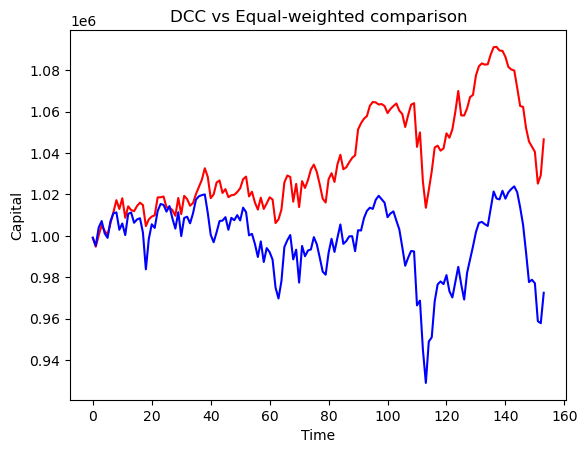

In [69]:
plt.plot(capital_list, color='red')
plt.plot(capital_equal_list, color='blue')
plt.xlabel('Time')
plt.ylabel('Capital')
plt.title('DCC vs Equal-weighted comparison')
plt.show()

In [71]:
list_of_sharpe_ratio_DCC = []
list_of_sharpe_ratio_equal_weighted = []
list_of_capital_list = []
list_of_capital_equal_list = []
frequency = 'DAILY'
for year in [2010, 2011]: #, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]:
    for month in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]:
        print(f'{year}-{month}')
        RESULT = all_steps_in_one_place_optuna(DOW_JONES_PARTLY, frequency=frequency, perspective='LONG',
            start=f'{year}-{month}-03 14:30:00', end=f'{year+2}-{month}-03 14:30:00', kernel='BASE_EMA',  train_fraction=0.7, method='NL', DCC_trials=20,
            goal_function='Sharpe Ratio', min_weight=0.0001, max_weight=0.2, budget=1)
        r_out = RESULT['Long details']['Returns list']
        w_opt_list_out = RESULT['Long details']['Weights list']
        summary_list, capital_list, capital_equal_list = DCC_strategy_report(r_out,
        w_opt_list_out, DOW_JONES_PARTLY, leverage=1, frequency=frequency, comission=0.0005, risk_free_rate=0.02)
        list_of_sharpe_ratio_DCC.append(summary_list['DCC Sharpe ratio'])
        list_of_sharpe_ratio_equal_weighted.append(summary_list['Sharpe ratio for equal wighted'])
        list_of_capital_list.append(capital_list)
        list_of_capital_equal_list.append(capital_equal_list)

2010-1


[I 2025-10-20 18:04:09,496] A new study created in memory with name: no-name-58f9381f-f534-4813-9b83-c3aeedcfc039
[I 2025-10-20 18:04:09,498] Trial 0 finished with value: -1229.917486793423 and parameters: {'omega_AXP': 5.274170599902423e-05, 'alpha_AXP': 0.13191499038921864, 'beta_AXP': 0.8144458770684468}. Best is trial 0 with value: -1229.917486793423.
[I 2025-10-20 18:04:09,499] Trial 1 finished with value: inf and parameters: {'omega_AXP': 1.0405417078632813e-05, 'alpha_AXP': 0.16718408475206598, 'beta_AXP': 0.9295871341926021}. Best is trial 0 with value: -1229.917486793423.
[I 2025-10-20 18:04:09,500] Trial 2 finished with value: -1233.912043598679 and parameters: {'omega_AXP': 7.874866136873522e-05, 'alpha_AXP': 0.0530320044651438, 'beta_AXP': 0.7732119726947817}. Best is trial 2 with value: -1233.912043598679.
[I 2025-10-20 18:04:09,502] Trial 3 finished with value: -1241.2145275002404 and parameters: {'omega_AXP': 5.8352768832686446e-05, 'alpha_AXP': 0.1311322854530216, 'beta

GARCH(1,1) optimization for AXP:
GARCH(1,1) optimization for AMGN:


[I 2025-10-20 18:04:09,714] Trial 16 finished with value: -1342.5135495223603 and parameters: {'omega_AMGN': 9.15838960670238e-06, 'alpha_AMGN': 0.08789880098697289, 'beta_AMGN': 0.8172215214284793}. Best is trial 10 with value: -1353.715455684745.
[I 2025-10-20 18:04:09,725] Trial 17 finished with value: -1288.9268040485886 and parameters: {'omega_AMGN': 2.438419985086606e-05, 'alpha_AMGN': 0.029499974030878787, 'beta_AMGN': 0.9382174683823914}. Best is trial 10 with value: -1353.715455684745.
[I 2025-10-20 18:04:09,736] Trial 18 finished with value: inf and parameters: {'omega_AMGN': 3.531138671852832e-05, 'alpha_AMGN': 0.19732528903191998, 'beta_AMGN': 0.8714051263445681}. Best is trial 10 with value: -1353.715455684745.
[I 2025-10-20 18:04:09,746] Trial 19 finished with value: inf and parameters: {'omega_AMGN': 9.079604798785608e-05, 'alpha_AMGN': 0.08091984636434091, 'beta_AMGN': 0.9416464165272849}. Best is trial 10 with value: -1353.715455684745.
[I 2025-10-20 18:04:09,748] A ne

GARCH(1,1) optimization for BA:
GARCH(1,1) optimization for CAT:


...

[I 2025-10-20 18:05:34,256] Trial 18 finished with value: -1472.2564352897703 and parameters: {'omega_PG': 1.0424386956037581e-05, 'alpha_PG': 0.057945618958847936, 'beta_PG': 0.8737882702349741}. Best is trial 0 with value: -1481.5742935765747.
[I 2025-10-20 18:05:34,266] Trial 19 finished with value: -1481.2807699899809 and parameters: {'omega_PG': 7.392745830870087e-06, 'alpha_PG': 0.05064416599317281, 'beta_PG': 0.8688684297439957}. Best is trial 0 with value: -1481.5742935765747.
[I 2025-10-20 18:05:34,268] A new study created in memory with name: no-name-40d4b94e-33a5-4655-ba54-4a88b98559fe
[I 2025-10-20 18:05:34,269] Trial 0 finished with value: -1160.9308071203882 and parameters: {'omega_CRM': 3.587173017416328e-06, 'alpha_CRM': 0.16684558613842315, 'beta_CRM': 0.8108170543278392}. Best is trial 0 with value: -1160.9308071203882.
[I 2025-10-20 18:05:34,270] Trial 1 finished with value: -323.8120969685251 and parameters: {'omega_CRM': 1.1783895382740045e-06, 'alpha_CRM': 0.03803

GARCH(1,1) optimization for CRM:
GARCH(1,1) optimization for VZ:
GARCH(1,1) optimization for WMT:


[I 2025-10-20 18:05:34,468] Trial 1 finished with value: inf and parameters: {'omega_WMT': 8.537099867180445e-06, 'alpha_WMT': 0.04821761067014408, 'beta_WMT': 0.9554246277609098}. Best is trial 0 with value: -1224.7041204186633.
[I 2025-10-20 18:05:34,469] Trial 2 finished with value: -1333.8145258789332 and parameters: {'omega_WMT': 6.582649572599198e-05, 'alpha_WMT': 0.1377940997248579, 'beta_WMT': 0.8062981327575391}. Best is trial 2 with value: -1333.8145258789332.
[I 2025-10-20 18:05:34,470] Trial 3 finished with value: -1338.4965515268793 and parameters: {'omega_WMT': 7.1524795781393724e-06, 'alpha_WMT': 0.042825160115170326, 'beta_WMT': 0.708733293981358}. Best is trial 3 with value: -1338.4965515268793.
[I 2025-10-20 18:05:34,471] Trial 4 finished with value: -1054.284976767302 and parameters: {'omega_WMT': 7.233808504338374e-05, 'alpha_WMT': 0.01941914688203334, 'beta_WMT': 0.97330367067042}. Best is trial 3 with value: -1338.4965515268793.
[I 2025-10-20 18:05:34,473] Trial 5

GARCH(1,1) optimization for DIS:
GARCH(1,1) optimization for T:


[I 2025-10-20 18:05:34,776] A new study created in memory with name: no-name-9cf97278-0fa6-4813-ae2b-56e3b7a2d3e7
[I 2025-10-20 18:05:34,900] Trial 0 finished with value: 50560.38173638709 and parameters: {'alpha': 0.03, 'beta': 0.94}. Best is trial 0 with value: 50560.38173638709.


In [72]:
print(list_of_sharpe_ratio_DCC)
print(list_of_sharpe_ratio_equal_weighted)

[-0.506, 1.247, 1.445, 2.219, 2.981, 2.263, 3.955, 3.634, 3.378, 2.737, 1.805, 1.537, 1.497, 2.343, 1.687, 1.71, 2.467, 3.191, 2.065, 2.29, 2.318, 1.848, 2.069, 2.195]
[0.1, 0.485, 0.726, 1.52, 2.117, 0.903, 2.225, 1.591, 1.307, 1.263, 0.458, 0.503, 1.386, 1.699, 1.96, 1.742, 1.865, 2.432, 2.035, 2.926, 1.256, 1.049, 1.31, 1.079]


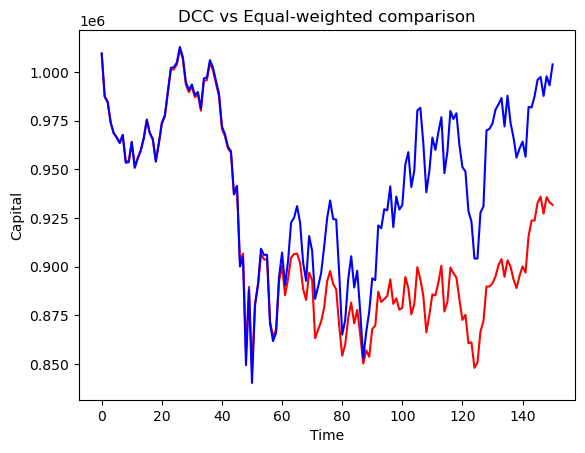

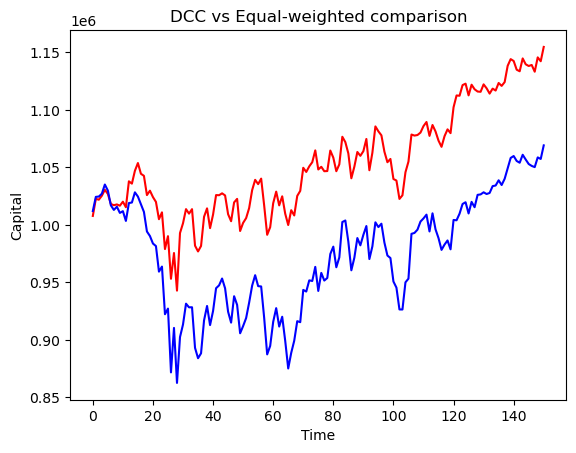

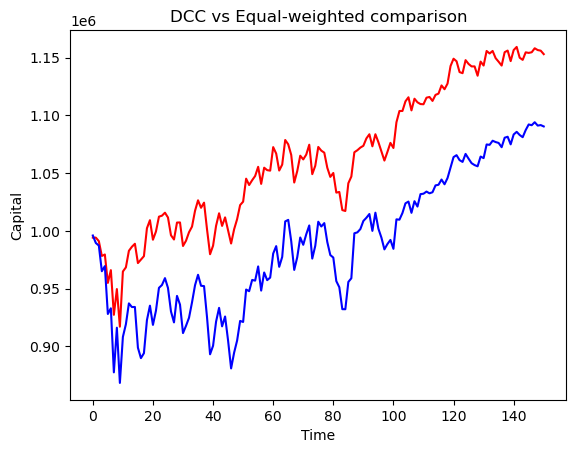

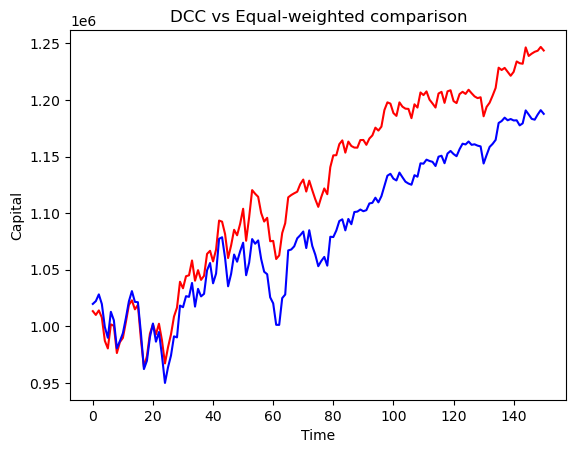

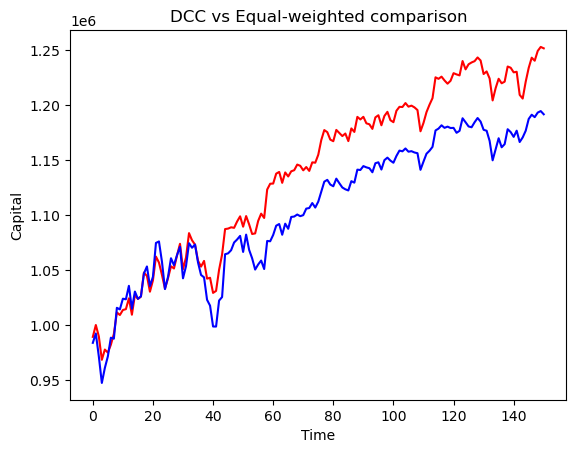

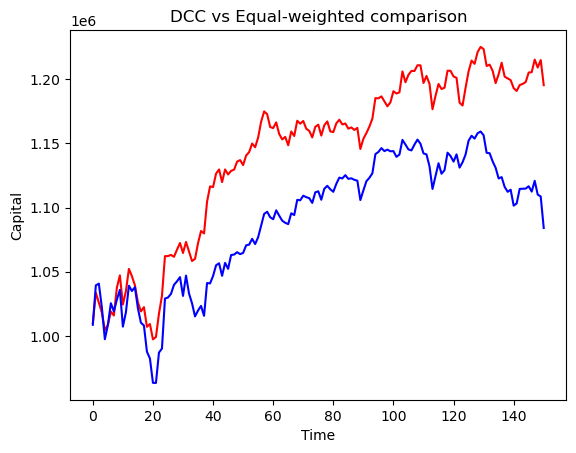

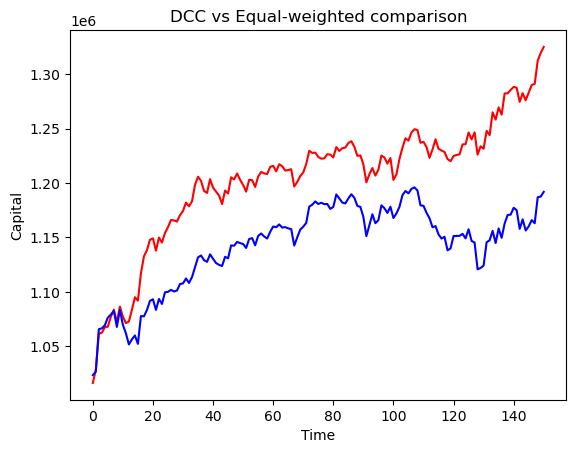

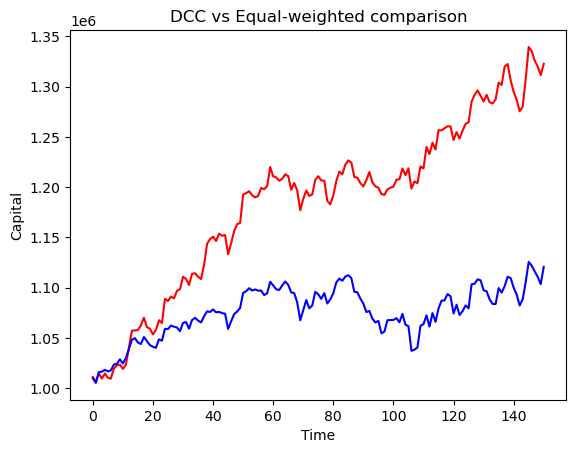

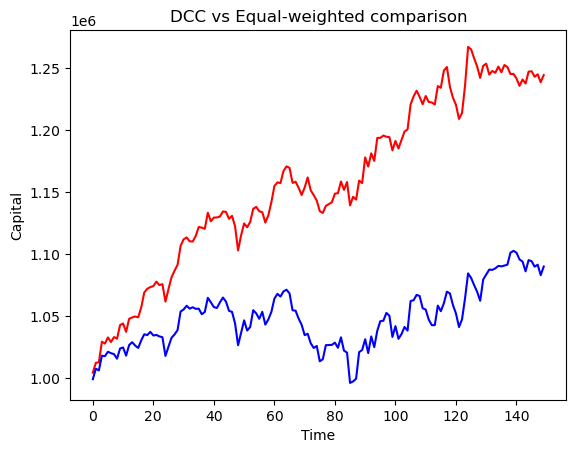

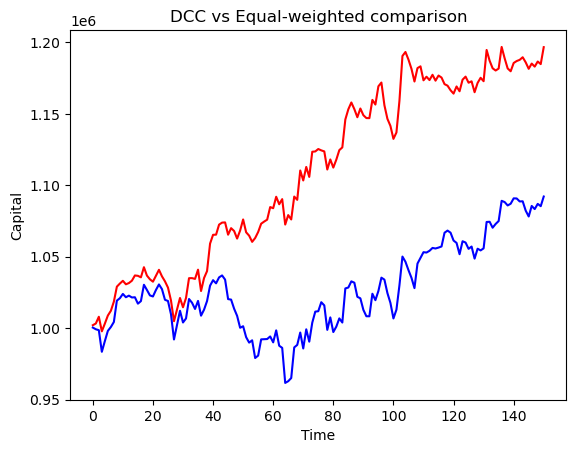

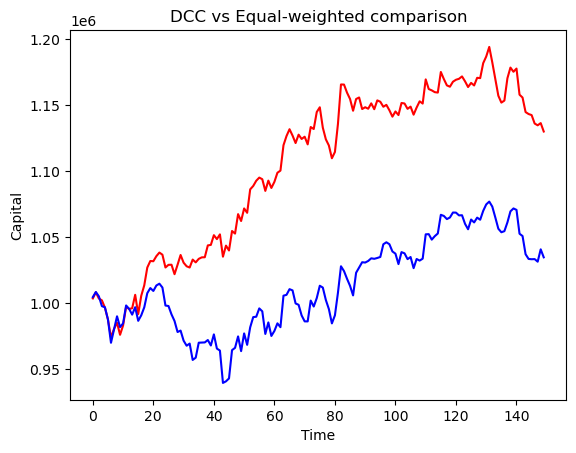

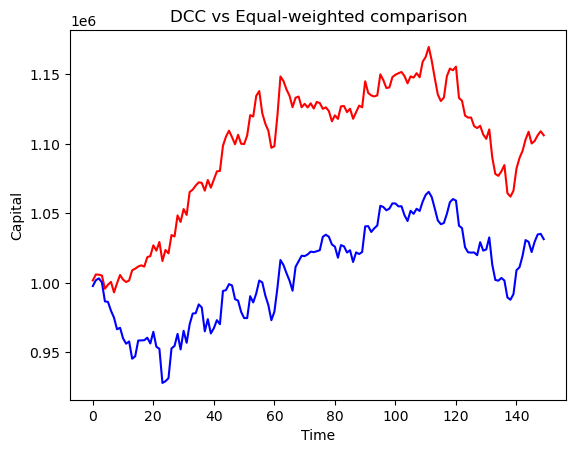

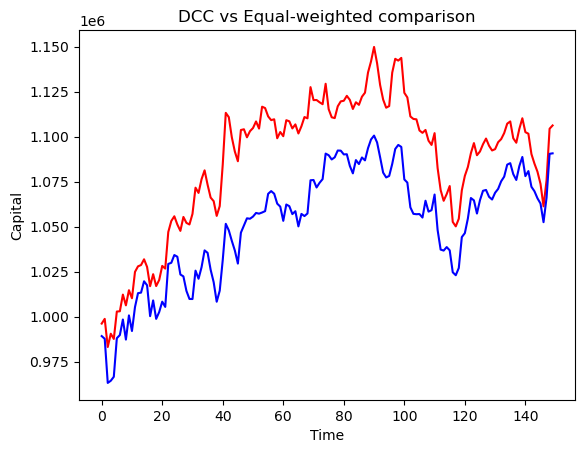

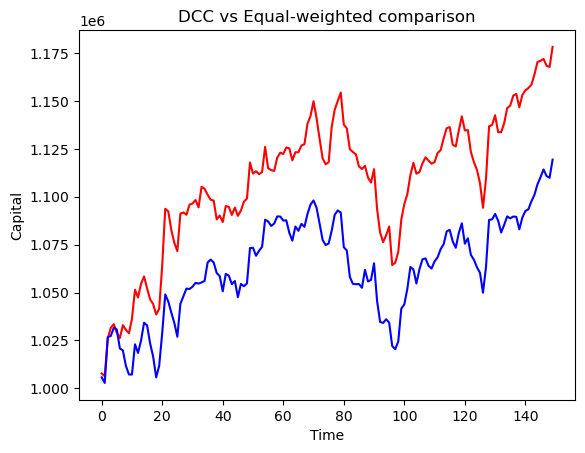

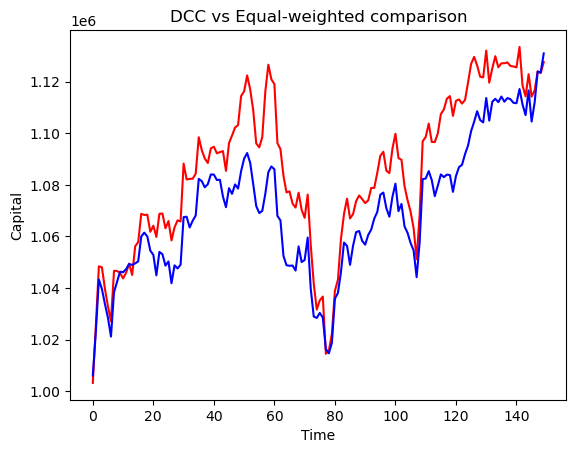

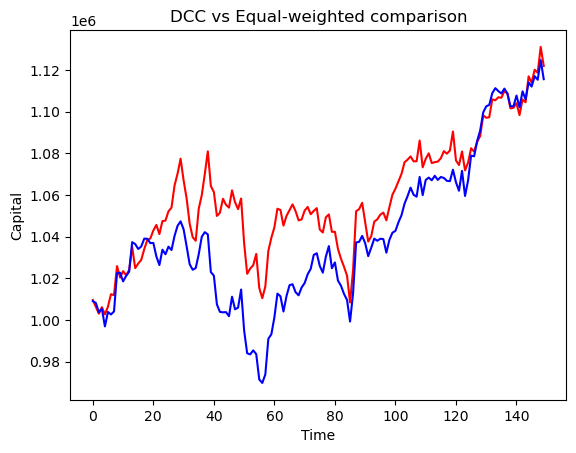

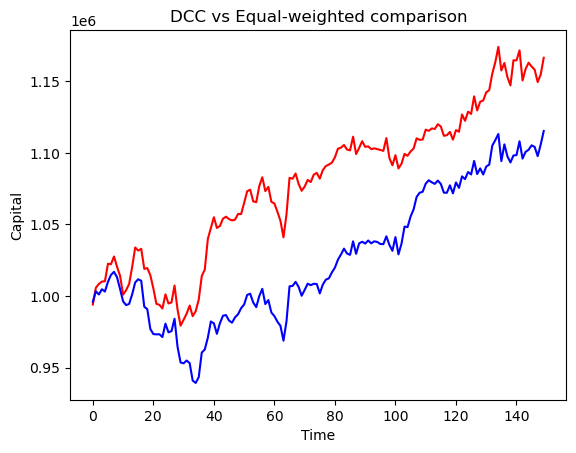

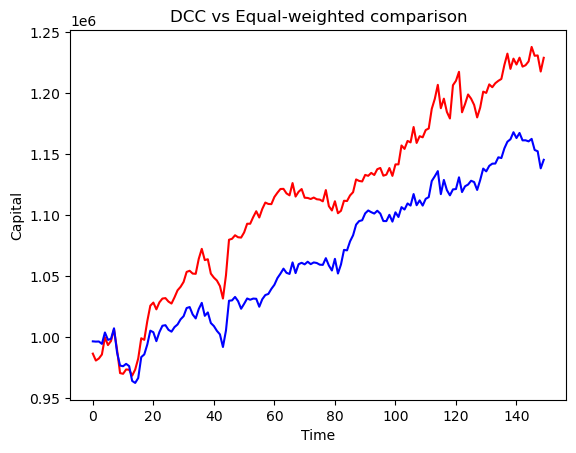

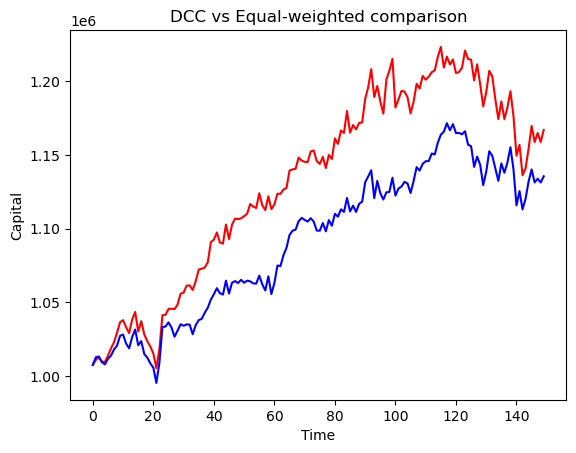

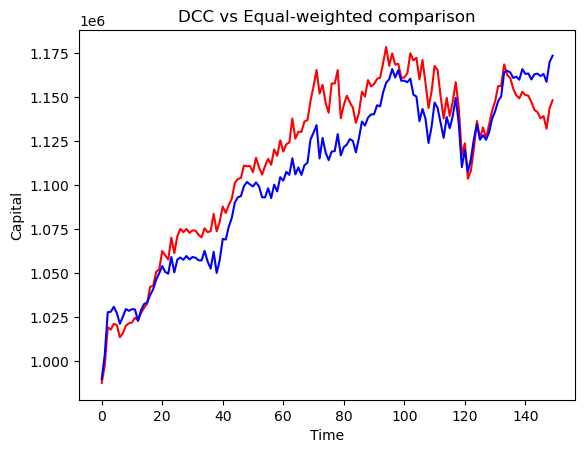

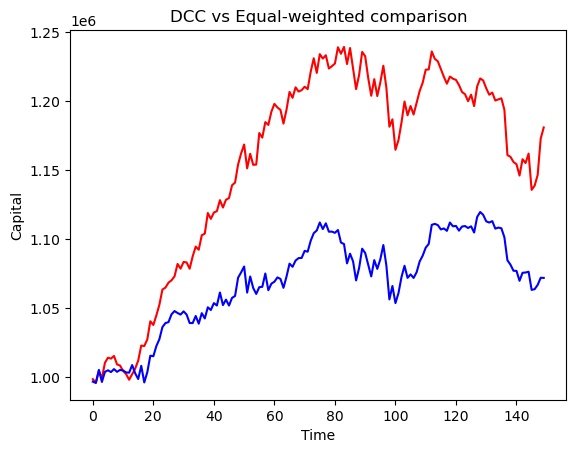

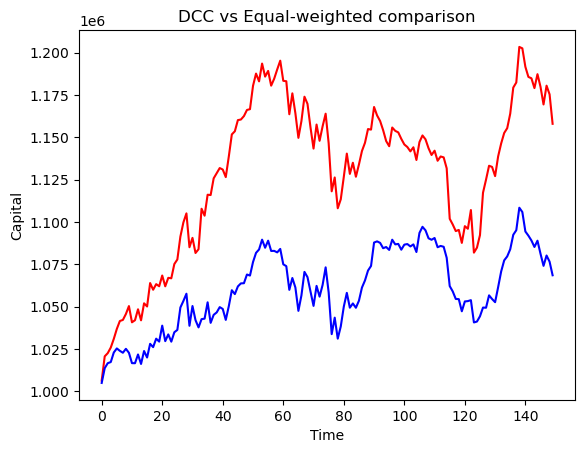

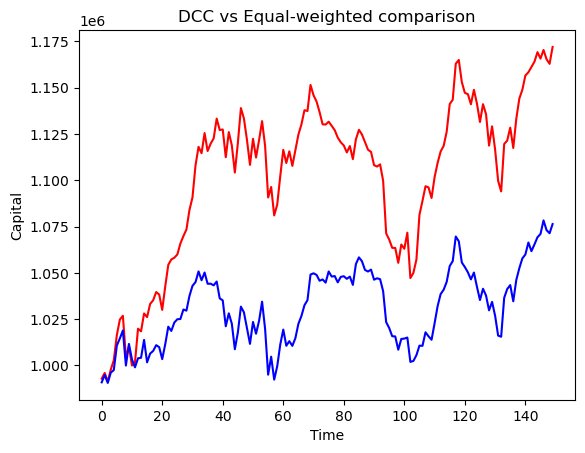

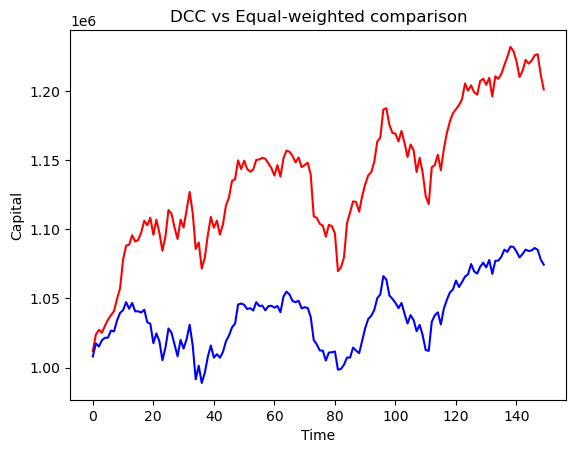

In [73]:
for capital_list, capital_equal_list in zip(list_of_capital_list, list_of_capital_equal_list):
    plt.plot(capital_list, color='red')
    plt.plot(capital_equal_list, color='blue')
    plt.xlabel('Time')
    plt.ylabel('Capital')
    plt.title('DCC vs Equal-weighted comparison')
    plt.show()

In [74]:
print(np.mean(list_of_sharpe_ratio_DCC))

2.1822916666666665


In [75]:
print(np.mean((list_of_sharpe_ratio_equal_weighted)))

1.4140416666666666


In [76]:
DCC_superiority = []
for capital_list, capital_equal_list in zip(list_of_capital_list, list_of_capital_equal_list):
    print(capital_list[-1] / capital_equal_list[-1])
    DCC_superiority.append(capital_list[-1] / capital_equal_list[-1])

0.928134479479764
1.080053958190354
1.0574257715082087
1.0471273260937481
1.050337320827563
1.1026864711691176
1.1116466144080739
1.1800417450783243
1.1417763752266772
1.0956817008521889
1.0921416659733494
1.072397895169062
1.0142040980176785
1.0525371694832202
0.997024034385466
1.0056829234577562
1.0458772466807635
1.0730921203557506
1.0276999307191783
0.9784198897712275
1.101759667011167
1.0836689367711991
1.0888734725054252
1.118010097956908


In [77]:
print(np.mean(DCC_superiority))

1.0644292046288406


## Additional exercises and research topics:

* Explore non-Gaussian innovations (e.g. Student-t DCC).

* Try RNN/LSTM models for return forecasting.

* Introduce asymmetric DCC (ADCC) dynamics.

* Evaluate alternative portfolio objectives (e.g. risk parity, CVaR).

* Benchmark vs other volatility models (EWMA, OGARCH, BEKK).